In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/FranchiseOps_AI_4_Combined_Dataset.xlsx')
df

,Record_ID,Outlet_ID,Outlet_Name,Outlet_Type,City,State,Region,Month,Footfall,Orders,...,Profitability_Improvement_Score,Audit_Risk_Score,Audit_Risk_Level,Audit_Status,Audit_Flag,Executive_Recommendation,Inventory_Agent_Efficiency_%,Staff_Agent_Productivity_%,Marketing_Agent_ROI_Tracking_%,Overall_Agent_Performance_%
0,REC000001,OUT0706,Franchise Outlet 0706,Franchise,Vadodara,Gujarat,West,2024-03,8022.0,1564.0,...,89.25,35.66,Medium,Needs Attention,Operational controls need attention,Monitor and improve risk areas,60.0,100.00,78.25,79.47
1,REC000002,OUT0626,Franchise Outlet 0626,Franchise,Bhubaneswar,Odisha,East,2026-01,10528.0,1920.0,...,92.68,31.47,Medium,Needs Attention,Operational controls need attention,Monitor and improve risk areas,64.9,100.00,86.25,83.59
2,REC000003,OUT0296,Franchise Outlet 0296,Franchise,Bhubaneswar,Odisha,East,2026-01,5894.0,1501.0,...,70.62,30.18,Medium,Needs Attention,Operational controls need attention,Monitor and improve risk areas,84.9,64.71,68.50,72.91
3,REC000004,OUT0670,Franchise Outlet 0670,Franchise,Pune,Maharashtra,West,2026-01,4275.0,644.0,...,64.84,43.02,Medium,Needs Attention,Operational controls need attention,Monitor and improve risk areas,41.6,49.98,69.75,52.98
4,REC000005,OUT0734,Franchise Outlet 0734,Company-Owned,Nagpur,Maharashtra,West,2024-10,10713.0,3235.0,...,95.49,15.54,Low,Compliant,No major audit issue,Continue routine monitoring,77.2,100.00,100.00,92.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30115,REC030116,OUT0162,Franchise Outlet 0162,Franchise,Surat,Gujarat,West,2026-02,4546.0,716.0,...,81.17,28.73,Low,Needs Attention,Operational controls need attention,Continue routine monitoring,84.8,43.10,60.00,62.76
30116,REC030117,OUT0463,Franchise Outlet 0463,Franchise,Indore,Madhya Pradesh,West,2025-06,11674.0,3382.0,...,95.98,24.21,Low,Compliant,No major audit issue,Continue routine monitoring,81.7,95.81,100.00,92.13
30117,REC030118,OUT0741,Franchise Outlet 0741,Franchise,Kochi,Kerala,South,2025-01,5803.0,1083.0,...,56.72,40.25,Medium,Needs Attention,Operational controls need attention,Monitor and improve risk areas,65.1,54.69,87.50,68.18
30118,REC030119,OUT0225,Franchise Outlet 0225,Franchise,Nashik,Maharashtra,West,2025-03,7990.0,1126.0,...,62.95,42.76,Medium,Needs Attention,Operational controls need attention,Monitor and improve risk areas,63.3,100.00,100.00,87.16


In [ ]:
df.head(2)

,Record_ID,Outlet_ID,Outlet_Name,Outlet_Type,City,State,Region,Month,Footfall,Orders,...,Profitability_Improvement_Score,Audit_Risk_Score,Audit_Risk_Level,Audit_Status,Audit_Flag,Executive_Recommendation,Inventory_Agent_Efficiency_%,Staff_Agent_Productivity_%,Marketing_Agent_ROI_Tracking_%,Overall_Agent_Performance_%
0,REC000001,OUT0706,Franchise Outlet 0706,Franchise,Vadodara,Gujarat,West,2024-03,8022.0,1564.0,...,89.25,35.66,Medium,Needs Attention,Operational controls need attention,Monitor and improve risk areas,60.0,100.0,78.25,79.47
1,REC000002,OUT0626,Franchise Outlet 0626,Franchise,Bhubaneswar,Odisha,East,2026-01,10528.0,1920.0,...,92.68,31.47,Medium,Needs Attention,Operational controls need attention,Monitor and improve risk areas,64.9,100.0,86.25,83.59


In [ ]:
df.tail(2)

,Record_ID,Outlet_ID,Outlet_Name,Outlet_Type,City,State,Region,Month,Footfall,Orders,...,Profitability_Improvement_Score,Audit_Risk_Score,Audit_Risk_Level,Audit_Status,Audit_Flag,Executive_Recommendation,Inventory_Agent_Efficiency_%,Staff_Agent_Productivity_%,Marketing_Agent_ROI_Tracking_%,Overall_Agent_Performance_%
30118,REC030119,OUT0225,Franchise Outlet 0225,Franchise,Nashik,Maharashtra,West,2025-03,7990.0,1126.0,...,62.95,42.76,Medium,Needs Attention,Operational controls need attention,Monitor and improve risk areas,63.3,100.00,100.00,87.16
30119,REC030120,OUT0058,Franchise Outlet 0058,Franchise,Patna,Bihar,East,2025-02,5722.0,1125.0,...,87.09,29.10,Low,Needs Attention,Operational controls need attention,Continue routine monitoring,52.3,73.42,67.25,64.18


In [ ]:
df.describe()

,Footfall,Orders,Conversion_Rate_%,Average_Order_Value_INR,Sales_Revenue_INR,COGS_INR,Operating_Cost_INR,Marketing_Spend_INR,Profit_INR,Profit_Margin_%,...,Campaign_ROI,Audit_Compliance_Score,Franchise_Health_Score,Operational_Efficiency_Score,Profitability_Improvement_Score,Audit_Risk_Score,Inventory_Agent_Efficiency_%,Staff_Agent_Productivity_%,Marketing_Agent_ROI_Tracking_%,Overall_Agent_Performance_%
count,29880.000000,29938.000000,29818.000000,29880.000000,3.012000e+04,3.012000e+04,3.012000e+04,29820.000000,3.012000e+04,30120.000000,...,30120.000000,30120.000000,30120.000000,30120.000000,30120.000000,30120.000000,30120.000000,30120.000000,30120.000000,30120.000000
mean,6907.465763,1607.975115,22.266748,1136.441544,1.825154e+06,1.003977e+06,4.013059e+05,91183.768682,3.287114e+05,18.018755,...,1.844893,68.363176,71.990415,69.804613,82.955070,31.636822,60.866444,70.569513,86.958342,72.089965
std,3415.440419,1075.343491,6.418523,386.984856,1.428852e+06,7.980363e+05,3.327136e+05,81594.633265,3.100897e+05,7.609440,...,1.101325,7.449073,8.450773,9.709749,11.158035,7.449074,23.074638,23.234719,13.073982,13.110540
min,1151.000000,131.000000,7.210000,417.400000,8.276198e+04,4.303380e+04,1.378135e+04,2172.640000,-1.119826e+05,-1.970000,...,-0.810000,39.320000,40.840000,37.570000,40.140000,8.150000,0.000000,27.380000,29.750000,27.960000
25%,4111.000000,787.000000,17.660000,822.922500,8.031996e+05,4.374070e+05,1.678130e+05,35840.095000,1.191360e+05,12.520000,...,1.070000,63.360000,66.240000,62.760000,75.960000,26.397500,43.900000,50.002500,76.750000,62.760000
50%,6408.000000,1304.000000,21.550000,1149.470000,1.399180e+06,7.636815e+05,2.994239e+05,65372.920000,2.320916e+05,18.040000,...,1.570000,68.490000,72.330000,69.770000,86.230000,31.510000,59.900000,68.765000,89.250000,72.440000
75%,9338.000000,2182.000000,26.560000,1459.285000,2.411703e+06,1.327392e+06,5.291099e+05,119629.745000,4.353322e+05,23.480000,...,2.420000,73.602500,78.040000,76.600000,91.870000,36.640000,78.225000,100.000000,100.000000,81.730000
max,18419.000000,7143.000000,46.190000,1941.780000,1.146204e+07,7.031556e+06,3.288607e+06,832533.540000,2.889860e+06,38.770000,...,20.250000,91.850000,98.100000,98.630000,99.280000,60.680000,100.000000,100.000000,100.000000,100.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30120 entries, 0 to 30119
Data columns (total 66 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Record_ID                         30120 non-null  object 
 1   Outlet_ID                         30120 non-null  object 
 2   Outlet_Name                       30120 non-null  object 
 3   Outlet_Type                       30120 non-null  object 
 4   City                              30120 non-null  object 
 5   State                             30120 non-null  object 
 6   Region                            30120 non-null  object 
 7   Month                             30120 non-null  object 
 8   Footfall                          29880 non-null  float64
 9   Orders                            29938 non-null  float64
 10  Conversion_Rate_%                 29818 non-null  float64
 11  Average_Order_Value_INR           29880 non-null  float64
 12  Sale

In [ ]:
df["Month"] = pd.to_datetime(df["Month"], errors="coerce")
print(df["Month"].dtype)

datetime64[ns]


In [ ]:
df.shape

(30120, 66)

In [ ]:
df.columns.to_list()

['Record_ID',
 'Outlet_ID',
 'Outlet_Name',
 'Outlet_Type',
 'City',
 'State',
 'Region',
 'Month',
 'Footfall',
 'Orders',
 'Conversion_Rate_%',
 'Average_Order_Value_INR',
 'Sales_Revenue_INR',
 'COGS_INR',
 'Operating_Cost_INR',
 'Marketing_Spend_INR',
 'Profit_INR',
 'Profit_Margin_%',
 'Employees',
 'Employee_Turnover_%',
 'Customer_Satisfaction_1_5',
 'Complaints',
 'Product_Category',
 'Product_Type',
 'SKU_ID',
 'Inventory_Units_Sold',
 'Opening_Stock_Units',
 'Stock_Received_Units',
 'Closing_Stock_Units',
 'Safety_Stock_Units',
 'Supplier_Lead_Time_Days',
 'Reorder_Point_Units',
 'Demand_Forecast_Next_Month_Units',
 'Stock_Status',
 'Replenishment_Required',
 'Recommended_Replenishment_Units',
 'Stock_Availability_%',
 'Inventory_Turnover_Ratio',
 'Wastage_Units',
 'Freshness_Rate_%',
 'Shelf_Life_Days',
 'Staff_Productivity_Score',
 'Attendance_Rate_%',
 'Staff_Performance_Score',
 'Staff_Performance_Category',
 'Workforce_Scheduling_Status',
 'Campaign_ID',
 'Campaign_Type'

In [ ]:
df.isnull().sum()

,0
Record_ID,0
Outlet_ID,0
Outlet_Name,0
Outlet_Type,0
City,0
...,...
Executive_Recommendation,0
Inventory_Agent_Efficiency_%,0
Staff_Agent_Productivity_%,0
Marketing_Agent_ROI_Tracking_%,0


In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
print("\n" + "=" * 60)
print("5. ID CONSISTENCY CHECK")
print("=" * 60)

df["Outlet_ID"] = df["Outlet_ID"].astype(str).str.strip()
df["SKU_ID"] = df["SKU_ID"].astype(str).str.strip()
df["Campaign_ID"] = df["Campaign_ID"].astype(str).str.strip()

blank_outlet = (df["Outlet_ID"] == "").sum()
blank_sku = (df["SKU_ID"] == "").sum()
blank_campaign = (df["Campaign_ID"] == "").sum()

print("Blank Outlet_ID:", blank_outlet)
print("Blank SKU_ID:", blank_sku)
print("Blank Campaign_ID:", blank_campaign)

if blank_outlet == 0 and blank_sku == 0 and blank_campaign == 0:
    print("PASS - IDs are complete and consistent.")
else:
    print("CHECK - Blank IDs found.")



5. ID CONSISTENCY CHECK
Blank Outlet_ID: 0
Blank SKU_ID: 0
Blank Campaign_ID: 0
PASS - IDs are complete and consistent.


In [ ]:
df.shape


(30120, 66)

In [ ]:
percentage_columns = ["Conversion_Rate_%","Profit_Margin_%","Employee_Turnover_%","Stock_Availability_%","Freshness_Rate_%","Attendance_Rate_%","Customer_Engagement_Rate_%","Inventory_Agent_Efficiency_%","Staff_Agent_Productivity_%","Marketing_Agent_ROI_Tracking_%","Overall_Agent_Performance_%"]

for col in percentage_columns:
    median = df[col][df[col].between(0, 100)].median()
    df.loc[(df[col] < 0) | (df[col] > 100), col] = median


In [ ]:
print("=" * 60)
print("FRANCHISEOPS AI - M4 DATA VALIDATION")
print("=" * 60)

print("\n1. DATASET SIZE")
print("Rows    :", len(df))
print("Columns :", len(df.columns))

print("\n2. REQUIRED COLUMN CHECK")

required_columns = [
        "Outlet_ID",
        "SKU_ID",
        "Month",
        "Footfall",
        "Orders",
        "Sales_Revenue_INR",
        "Employees",
        "Inventory_Units_Sold",
        "Campaign_ID",
        "Audit_Compliance_Score",
        "Audit_Risk_Score",
        "Audit_Status",
        "Audit_Flag"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if not missing_columns:
    print("PASS - Required columns are present.")
else:
    print("FAIL - Missing columns:", missing_columns)


print("\n3. MISSING VALUE CHECK")
missing_values = df.isnull().sum().sum()
print("Total missing values:", missing_values)
if missing_values == 0:
    print("PASS - No missing values found.")
else:
    print("FAIL - Missing values found.")


print("\n4. DUPLICATE CHECK")
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)
if duplicates == 0:
    print("PASS - No duplicate rows found.")
else:
    print("FAIL - Duplicate rows found.")


print("\n5. MONTH DATA TYPE CHECK")
df["Month"] = pd.to_datetime(df["Month"], errors="coerce")
invalid_month = df["Month"].isnull().sum()
print("Month dtype:", df["Month"].dtype)
print("Invalid Month values:", invalid_month)
if invalid_month == 0:
    print("PASS - Month has valid datetime values.")
else:
    print("FAIL - Invalid Month values found.")


print("\n6. NUMERIC DATA TYPE CHECK")
numeric_columns = [
    "Footfall",
    "Orders",
    "Conversion_Rate_%",
    "Average_Order_Value_INR",
    "Sales_Revenue_INR",
    "COGS_INR",
    "Operating_Cost_INR",
    "Marketing_Spend_INR",
    "Profit_INR",
    "Profit_Margin_%",
    "Employees",
    "Employee_Turnover_%",
    "Customer_Satisfaction_1_5",
    "Complaints",
    "Inventory_Units_Sold",
    "Opening_Stock_Units",
    "Stock_Received_Units",
    "Closing_Stock_Units",
    "Safety_Stock_Units",
    "Supplier_Lead_Time_Days",
    "Reorder_Point_Units",
    "Demand_Forecast_Next_Month_Units",
    "Recommended_Replenishment_Units",
    "Stock_Availability_%",
    "Inventory_Turnover_Ratio",
    "Wastage_Units",
    "Freshness_Rate_%",
    "Shelf_Life_Days",
    "Staff_Productivity_Score",
    "Attendance_Rate_%",
    "Staff_Performance_Score",
    "Marketing_Reach",
    "Marketing_Conversions",
    "Customer_Engagement_Rate_%",
    "Campaign_ROI",
    "Audit_Compliance_Score",
    "Franchise_Health_Score",
    "Operational_Efficiency_Score",
    "Profitability_Improvement_Score",
    "Audit_Risk_Score",
    "Inventory_Agent_Efficiency_%",
    "Staff_Agent_Productivity_%",
    "Marketing_Agent_ROI_Tracking_%",
    "Overall_Agent_Performance_%"]

wrong_dtype = []

for col in numeric_columns:
    if col in df.columns:
        if not pd.api.types.is_numeric_dtype(df[col]):
            wrong_dtype.append(col)

if not wrong_dtype:
    print("PASS - Numeric columns have correct data types.")
else:
    print("CHECK - Non-numeric columns found:")
    print(wrong_dtype)

print("\n7. ID CONSISTENCY CHECK")

blank_outlet = df["Outlet_ID"].astype(str).str.strip().isin(["", "nan"]).sum()
blank_sku = df["SKU_ID"].astype(str).str.strip().isin(["", "nan"]).sum()

print("Blank Outlet_ID:", blank_outlet)
print("Blank SKU_ID   :", blank_sku)

if blank_outlet == 0 and blank_sku == 0:
    print("PASS - Outlet_ID and SKU_ID are complete.")
else:
    print("FAIL - Blank IDs found.")

print("\n8. PERCENTAGE RANGE CHECK")
percentage_columns = [
    "Conversion_Rate_%",
    "Profit_Margin_%",
    "Employee_Turnover_%",
    "Stock_Availability_%",
    "Freshness_Rate_%",
    "Attendance_Rate_%",
    "Customer_Engagement_Rate_%",
    "Inventory_Agent_Efficiency_%",
    "Staff_Agent_Productivity_%",
    "Marketing_Agent_ROI_Tracking_%",
    "Overall_Agent_Performance_%"
]

percentage_errors = {}

for col in percentage_columns:
    if col in df.columns:
        invalid = ((df[col] < 0) | (df[col] > 100)).sum()
        if invalid > 0:
            percentage_errors[col] = invalid

if not percentage_errors:
    print("PASS - Percentage values are within 0-100.")
else:
    print("FAIL - Invalid percentage values:")
    print(percentage_errors)

print("\n9. NEGATIVE VALUE CHECK")
non_negative_columns = ["Footfall","Orders","Sales_Revenue_INR","COGS_INR","Operating_Cost_INR","Marketing_Spend_INR","Employees","Complaints","Inventory_Units_Sold","Opening_Stock_Units","Stock_Received_Units","Closing_Stock_Units","Wastage_Units"]
negative_errors = {}
for col in non_negative_columns:
    if col in df.columns:
        count = (df[col] < 0).sum()
        if count > 0:
            negative_errors[col] = count

if not negative_errors:
    print("PASS - No negative values found.")
else:
    print("FAIL - Negative values found:")
    print(negative_errors)

print("\n" + "=" * 60)
print("FINAL VALIDATION RESULT")
print("=" * 60)
if (
    len(df) == 30120
    and len(df.columns) == 66
    and missing_values == 0
    and duplicates == 0
    and invalid_month == 0
    and not missing_columns
    and not wrong_dtype
    and blank_outlet == 0
    and blank_sku == 0
    and not percentage_errors
    and not negative_errors
):
    print("PASS - M4 DATASET VALIDATION COMPLETED SUCCESSFULLY.")
else:
    print("CHECK - Some validation issues require review.")

FRANCHISEOPS AI - M4 DATA VALIDATION

1. DATASET SIZE
Rows    : 30120
Columns : 66

2. REQUIRED COLUMN CHECK
PASS - Required columns are present.

3. MISSING VALUE CHECK
Total missing values: 0
PASS - No missing values found.

4. DUPLICATE CHECK
Duplicate rows: 0
PASS - No duplicate rows found.

5. MONTH DATA TYPE CHECK
Month dtype: datetime64[ns]
Invalid Month values: 0
PASS - Month has valid datetime values.

6. NUMERIC DATA TYPE CHECK
PASS - Numeric columns have correct data types.

7. ID CONSISTENCY CHECK
Blank Outlet_ID: 0
Blank SKU_ID   : 0
PASS - Outlet_ID and SKU_ID are complete.

8. PERCENTAGE RANGE CHECK
PASS - Percentage values are within 0-100.

9. NEGATIVE VALUE CHECK
PASS - No negative values found.

FINAL VALIDATION RESULT
PASS - M4 DATASET VALIDATION COMPLETED SUCCESSFULLY.


# **# Exploratory Data Analysis**

Exploratory Data Analysis (EDA) is performed to understand the distribution and characteristics of the franchise operational variables.


**Audit Risk Level Distribution**

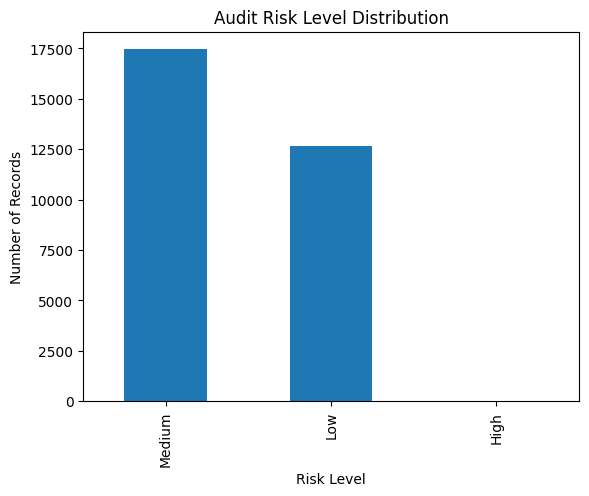

In [ ]:
df["Audit_Risk_Level"].value_counts().plot(kind="bar")

plt.title("Audit Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Records")
plt.show()

**Audit Compliance Score By Region**

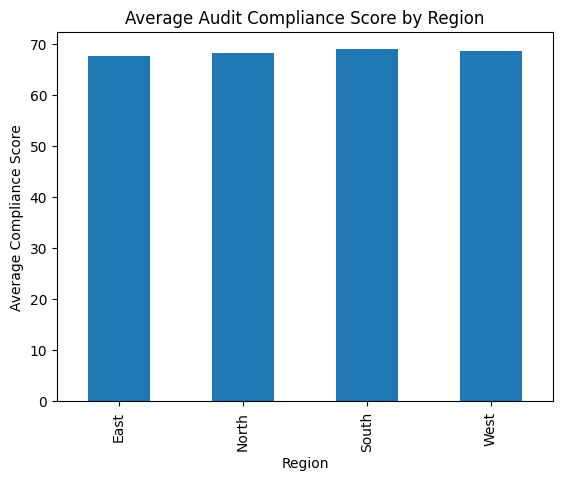

In [ ]:
df.groupby("Region")["Audit_Compliance_Score"].mean().plot(kind="bar")

plt.title("Average Audit Compliance Score by Region")
plt.xlabel("Region")
plt.ylabel("Average Compliance Score")
plt.show()

**Franchise Health Score By Region**

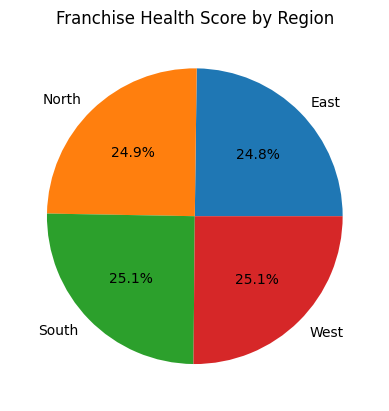

In [ ]:
df.groupby("Region")["Franchise_Health_Score"].mean().plot(kind="pie",autopct="%1.1f%%")

plt.title("Franchise Health Score by Region")
plt.ylabel("")
plt.show()

**Overall Agent Performance by Region**

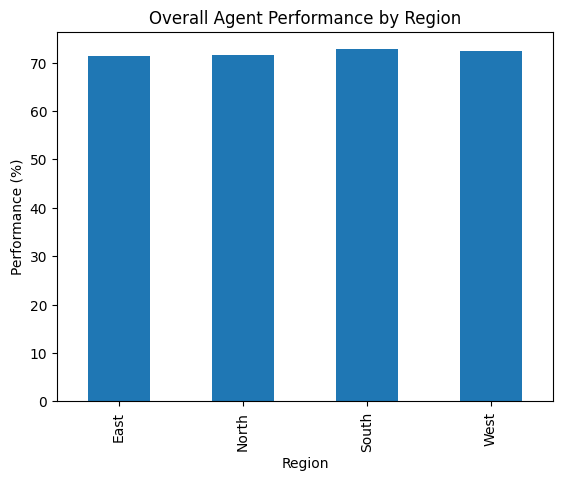

In [ ]:
df.groupby("Region")["Overall_Agent_Performance_%"].mean().plot(kind="bar")

plt.title("Overall Agent Performance by Region")
plt.xlabel("Region")
plt.ylabel("Performance (%)")
plt.show()

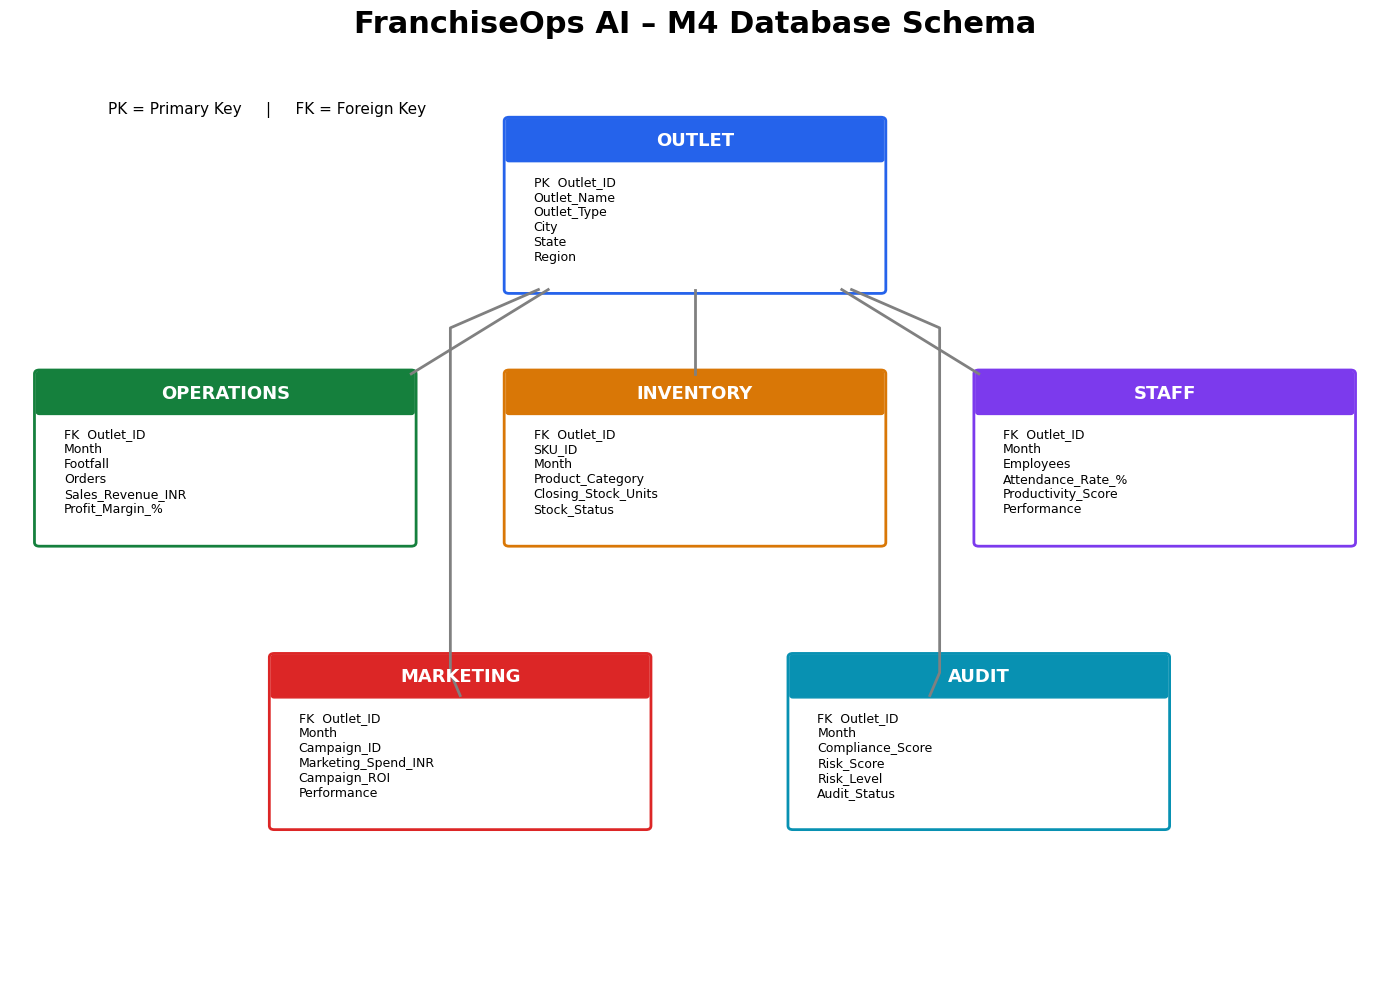

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(14, 10))

ax.set_xlim(0, 14)
ax.set_ylim(0, 12)
ax.axis("off")


def create_table(x, y, title, fields, color):


    box = FancyBboxPatch(
        (x, y),
        3.8, 2.2,
        boxstyle="round,pad=0.05",
        facecolor="white",
        edgecolor=color,
        linewidth=2
    )
    ax.add_patch(box)


    header = FancyBboxPatch(
        (x, y + 1.7),
        3.8, 0.5,
        boxstyle="round,pad=0.03",
        facecolor=color,
        edgecolor=color
    )
    ax.add_patch(header)

    ax.text(
        x + 1.9,
        y + 1.95,
        title,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color="white"
    )


    ax.text(
        x + 0.25,
        y + 1.5,
        "\n".join(fields),
        ha="left",
        va="top",
        fontsize=9
    )


# =========================
# OUTLET
# =========================

create_table(
    5.1, 9,
    "OUTLET",
    [
        "PK  Outlet_ID",
        "Outlet_Name",
        "Outlet_Type",
        "City",
        "State",
        "Region"
    ],
    "#2563EB"
)


# =========================
# OPERATIONS
# =========================

create_table(
    0.3, 5.7,
    "OPERATIONS",
    [
        "FK  Outlet_ID",
        "Month",
        "Footfall",
        "Orders",
        "Sales_Revenue_INR",
        "Profit_Margin_%"
    ],
    "#15803D"
)


# =========================
# INVENTORY
# =========================

create_table(
    5.1, 5.7,
    "INVENTORY",
    [
        "FK  Outlet_ID",
        "SKU_ID",
        "Month",
        "Product_Category",
        "Closing_Stock_Units",
        "Stock_Status"
    ],
    "#D97706"
)


# =========================
# STAFF
# =========================

create_table(
    9.9, 5.7,
    "STAFF",
    [
        "FK  Outlet_ID",
        "Month",
        "Employees",
        "Attendance_Rate_%",
        "Productivity_Score",
        "Performance"
    ],
    "#7C3AED"
)


# =========================
# MARKETING
# =========================

create_table(
    2.7, 2,
    "MARKETING",
    [
        "FK  Outlet_ID",
        "Month",
        "Campaign_ID",
        "Marketing_Spend_INR",
        "Campaign_ROI",
        "Performance"
    ],
    "#DC2626"
)


# =========================
# AUDIT
# =========================

create_table(
    8, 2,
    "AUDIT",
    [
        "FK  Outlet_ID",
        "Month",
        "Compliance_Score",
        "Risk_Score",
        "Risk_Level",
        "Audit_Status"
    ],
    "#0891B2"
)


# =========================
# CONNECTIONS
# =========================

# OUTLET → OPERATIONS
ax.plot(
    [5.5, 4.1],
    [9.0, 7.9],
    color="gray",
    linewidth=2
)

# OUTLET → INVENTORY
ax.plot(
    [7.0, 7.0],
    [9.0, 7.9],
    color="gray",
    linewidth=2
)

# OUTLET → STAFF
ax.plot(
    [8.5, 9.9],
    [9.0, 7.9],
    color="gray",
    linewidth=2
)

# OUTLET → MARKETING
ax.plot(
    [5.4, 4.5, 4.5, 4.6],
    [9.0, 8.5, 4.0, 3.7],
    color="gray",
    linewidth=2)

# OUTLET → AUDIT
ax.plot(
    [8.6, 9.5, 9.5, 9.4],
    [9.0, 8.5, 4.0, 3.7],
    color="gray",
    linewidth=2
)


# =========================
# TITLE
# =========================

plt.title(
    "FranchiseOps AI – M4 Database Schema",
    fontsize=22,
    fontweight="bold",
    pad=20
)

ax.text(1,11.3,
    "PK = Primary Key     |     FK = Foreign Key",
    ha="left",
    fontsize=11,
    color="black")

plt.tight_layout()
plt.show()